# EDA

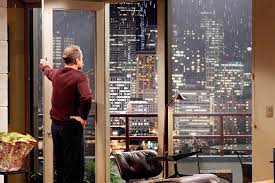

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_pickle("data/housing_cleaned.pkl")

**Zusammenfassung Phase 2:** Alle vier betroffenen Spalten sind jetzt vollständig, ohne dass wir Zeilen gelöscht oder Werte grob geraten haben – jede Entscheidung basiert auf einer inhaltlichen Begründung (dominanter Wert, Beziehung zwischen Spalten) oder auf einer verifizierten Korrektur.

---

## Hypothese 2 – "Renovation / Condition / Grade correspond to higher price points"

Diese Hypothese wurde mir (Sonson) vom Team zur Untersuchung zugeteilt. Sie deckt sich mit unserer Annahme zum "Condition Discount": Häuser mit durchschnittlichem Zustand (`condition == 3`) sollen einen günstigeren Einstiegspreis mit Renovierungspotenzial bieten. Wir prüfen das in zwei Schritten:

1. Zuerst auf dem **gesamten Datensatz**: Wie hängen `grade`, `condition` und Renovierungsstatus generell mit dem Preis zusammen?
2. Dann **gezielt in Bonnie Browns Budget-Segment** (`price <= 500.000`, `bedrooms >= 3`, `bathrooms >= 1.5`), auf Basis von `price / sqft_living` – denn ein absoluter Preisvergleich ist für sie irrelevant, ihr Budget ist ohnehin gedeckelt.

### 3.1 Preis nach `grade` (gesamter Datensatz)

`grade` ist King Countys eigenes Bewertungssystem für Bauqualität/-ausstattung (3 = niedrig, 13 = sehr hoch). Wir schauen uns die Preisverteilung je Grade-Stufe an.

       count     median          mean
grade                                
3          1   262000.0  2.620000e+05
4         27   200000.0  2.120019e+05
5        242   228700.0  2.485240e+05
6       2038   275276.5  3.019166e+05
7       8974   375000.0  4.025946e+05
8       6065   510000.0  5.429868e+05
9       2615   720000.0  7.737382e+05
10      1134   914327.0  1.072347e+06
11       399  1280000.0  1.497792e+06
12        89  1820000.0  2.202528e+06
13        13  2980000.0  3.710769e+06

Korrelation grade <-> price: 0.67


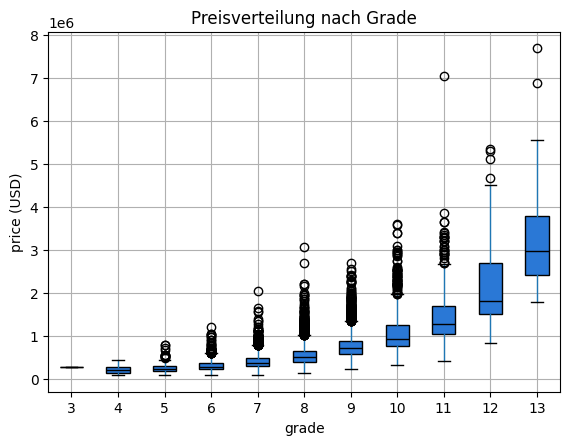

In [3]:
grade_price = df.groupby("grade")["price"].agg(["count", "median", "mean"])
print(grade_price)
print("\nKorrelation grade <-> price:", df["grade"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="grade", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preisverteilung nach Grade")
ax.set_xlabel("grade")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Sehr klarer, nahezu monotoner Zusammenhang – der Median-Preis steigt von 262.000 $ (Grade 3) auf 2.980.000 $ (Grade 13). Korrelation `grade` ↔ `price`: **0.67** – der stärkste Einzelfaktor, den wir bisher gesehen haben. Für Hypothese 2 heißt das: **Grade bestätigt die Hypothese eindeutig.**

**Observation:** A very clear, almost monotonic relationship — the median price rises from $262,000 (grade 3) to $2,980,000 (grade 13). Correlation `grade` ↔ `price`: **0.67** — the strongest single factor we've seen so far. For Hypothesis 2, this means: **grade clearly confirms the hypothesis.**

### 3.2 Preis nach `condition` (gesamter Datensatz)

`condition` bewertet den allgemeinen Erhaltungszustand (1 = schlecht, 5 = sehr gut).

           count    median           mean
condition                                
1             29  270000.0  341067.241379
2            170  279000.0  328178.758824
3          14020  450250.0  542173.057347
4           5677  440000.0  521374.450414
5           1701  526000.0  612577.742504

Korrelation condition <-> price: 0.04


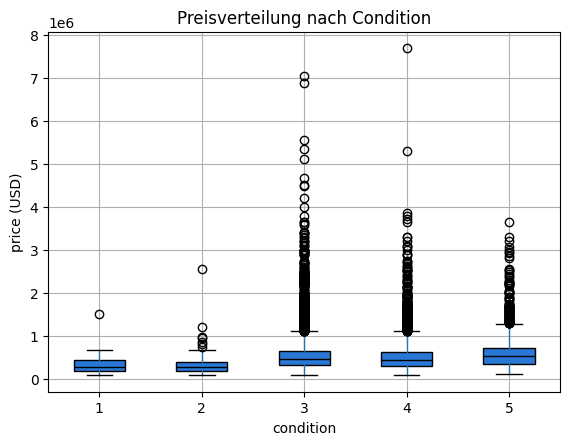

In [4]:
condition_price = df.groupby("condition")["price"].agg(["count", "median", "mean"])
print(condition_price)
print("\nKorrelation condition <-> price:", df["condition"].corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price", by="condition", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preisverteilung nach Condition")
ax.set_xlabel("condition")
ax.set_ylabel("price (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Anders als bei `grade` ist der Zusammenhang hier **schwach** – Korrelation `condition` ↔ `price`: nur **0.04**. `condition == 3` (Median 450.250 $) unterscheidet sich kaum von `condition == 4` (440.000 $) und liegt sogar leicht *unter* `condition == 5` (526.000 $), aber über `condition == 1`/`2` (kleine Stichproben, 29 bzw. 170 Häuser). Für Hypothese 2 heißt das: **`condition` allein erklärt den Preis über den gesamten Markt kaum** – der Effekt aus der Hypothese scheint fast ausschließlich über `grade` zu laufen, nicht über `condition`.

**Observation:** Unlike `grade`, the relationship here is **weak** — correlation `condition` ↔ `price`: only **0.04**. `condition == 3` (median $450,250) is barely different from `condition == 4` ($440,000), and even slightly *below* `condition == 5` ($526,000), though above `condition == 1`/`2` (small samples, 29 and 170 homes respectively). For Hypothesis 2, this means: **`condition` alone barely explains price across the whole market** — the effect implied by the hypothesis seems to run almost entirely through `grade`, not through `condition`.

### 3.3 Renovierte vs. nicht renovierte Häuser (gesamter Datensatz)

Wir leiten aus `yr_renovated` ein einfaches Flag `is_renovated` ab (`yr_renovated > 0`) und vergleichen sowohl den absoluten Preis als auch den Preis pro Quadratfuß (`price / sqft_living`), um Größeneffekte herauszurechnen.

              count    median           mean
is_renovated                                
False         20853  449000.0  532140.319858
True            744  607502.0  768901.892473

                  median        mean
is_renovated                        
False         243.190661  262.102755
True          301.562882  321.338135

Korrelation is_renovated <-> price: 0.12


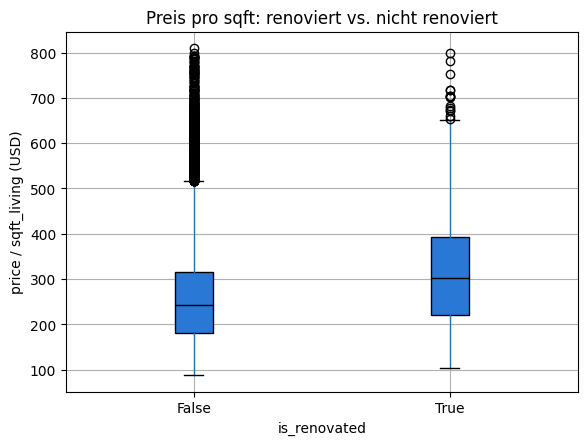

In [5]:
df["is_renovated"] = df["yr_renovated"] > 0
df["price_per_sqft"] = df["price"] / df["sqft_living"]

print(df.groupby("is_renovated")["price"].agg(["count", "median", "mean"]))
print()
print(df.groupby("is_renovated")["price_per_sqft"].agg(["median", "mean"]))
print("\nKorrelation is_renovated <-> price:", df["is_renovated"].astype(int).corr(df["price"]).round(2))

fig, ax = plt.subplots()
df.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
           boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
           medianprops={"color": "black"})
ax.set_title("Preis pro sqft: renoviert vs. nicht renoviert")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Renovierte Häuser (744 von 21.597, ca. 3.4 %) kosten median **607.502 $** vs. **449.000 $** bei nicht renovierten – auch pro Quadratfuß liegt der Median bei **302 $** vs. **243 $**. Korrelation `is_renovated` ↔ `price`: **0.12** – moderat, schwächer als `grade`, aber klar stärker als `condition`. Renovierung zeigt also einen sichtbaren Preisaufschlag.

**Observation:** Renovated homes (744 of 21,597, ~3.4%) sell for a median of **$607,502** vs. **$449,000** for non-renovated ones — the median price per square foot is also higher: **$302** vs. **$243**. Correlation `is_renovated` ↔ `price`: **0.12** — moderate, weaker than `grade` but clearly stronger than `condition`. Renovation does show a visible price premium.

### 3.4 Bonnies reale Rolle: Verkäuferin in einer Mittelschicht-Nachbarschaft

**Korrektur:** Die Analyse ab hier ging ursprünglich fälschlich davon aus, dass Bonnie eine Käuferin mit Budget ≤ 500.000 $ ist. Laut offizieller Aufgabenstellung (`01_assignment.md`) ist Bonnie Brown tatsächlich **Verkäuferin**: Sie besitzt bereits ein Haus in einer **Mittelschicht-Nachbarschaft** ("middle class NH"), will bald umziehen und dabei einen **möglichst hohen Profit** erzielen. Die Analyse ab 3.4 wurde entsprechend neu aufgesetzt – statt "günstig kaufen im Budget-Segment" geht es jetzt um "Profit beim Verkauf eines Mittelschicht-Hauses".

**Annahme (explizit, da der Datensatz keine Nachbarschafts-Klasse enthält):** Wir definieren "Mittelschicht-Nachbarschaft" über den **Zipcode-Median-Preis** – alle Zipcodes werden anhand ihres Median-Hauspreises in drei gleich große Gruppen (Terzile) eingeteilt: unteres, mittleres und oberes Preis-Drittel. Jedes Haus erbt die Klasse seines Zipcodes. Das mittlere Terzil = "middle class".

In [18]:
zip_median_price = df.groupby("zipcode")["price"].median()
neighborhood_class = pd.qcut(zip_median_price, 3, labels=["lower", "middle", "upper"])
df["neighborhood_class"] = df["zipcode"].map(neighborhood_class.to_dict())

print(df["neighborhood_class"].value_counts())
print("\nZipcode-Median-Preisspannen je Klasse:")
print(zip_median_price.groupby(neighborhood_class).agg(["min", "max", "count"]))

bonnie = df[df["neighborhood_class"] == "middle"].copy()
print(f"\nH\u00e4user in Mittelschicht-Nachbarschaften: {len(bonnie)} ({len(bonnie) / len(df):.1%} des Gesamtmarkts)")

neighborhood_class
lower     7795
upper     7011
middle    6791
Name: count, dtype: int64

Zipcode-Median-Preisspannen je Klasse:
              min         max  count
price                               
lower  235000.000  375000.000     25
middle 380000.000  554000.000     22
upper  555000.000 1895000.000     23

Häuser in Mittelschicht-Nachbarschaften: 6791 (31.4% des Gesamtmarkts)


**Beobachtung:** 70 Zipcodes verteilen sich auf drei etwa gleich große Gruppen. Die "middle"-Klasse (22 Zipcodes, 6.791 Häuser, ca. 31 % des Marktes) umfasst Zipcodes mit einem Median-Hauspreis zwischen 380.000 $ und 554.000 $ – eine klar mittlere Preisklasse zwischen den unteren (235.000–375.000 $, 25 Zipcodes) und oberen (555.000–1.895.000 $, 23 Zipcodes) Zipcode-Terzilen. Das ist unsere Arbeitsdefinition von "middle class neighborhood" für Bonnies Haus – `bonnie` bezeichnet ab jetzt alle Häuser in dieser Nachbarschaftsklasse, nicht mehr ein Budget-Segment.

#### `condition == 3` vs. andere Zustände – innerhalb der Mittelschicht-Nachbarschaften

In [19]:
bonnie.groupby(bonnie["condition"] == 3)["price_per_sqft"].agg(["count", "median", "mean"])

,count,median,mean
condition,,,
False,2352,276.219,293.831
True,4439,248.516,271.266


**Beobachtung:** Innerhalb der Mittelschicht-Nachbarschaften liegt der Median-Preis pro Quadratfuß bei `condition == 3` (4.439 Häuser) bei **249 $**, verglichen mit **276 $** bei besser bewerteten Zuständen (2.352 Häuser) – ein Abschlag von rund **10 %**. Anders als in der alten, budget-limitierten Analyse zeigt sich hier also durchaus ein Discount für durchschnittlichen Zustand. Für Bonnie heißt das: Wenn ihr Haus in `condition == 3` ist, verkauft es sich tendenziell günstiger pro Quadratfuß als besser erhaltene Häuser in derselben Nachbarschaftsklasse – genau die Ausgangslage, vor der sich die Frage nach einer Renovierung stellt.

#### ROI-Analyse: Lohnt sich eine Renovierung vor dem Verkauf?

Bonnies eigentliche Frage: Ihr Haus hat `condition == 3`. Würde eine Renovierung vor dem Verkauf den Gewinn ausreichend steigern, um sich zu lohnen? Wir vergleichen dazu bereits renovierte mit nicht renovierten Häusern, die *innerhalb* von `condition == 3` in Mittelschicht-Nachbarschaften verkauft wurden.

             price                       price_per_sqft                
             count     median       mean          count  median    mean
is_renovated                                                           
False         4238 465000.000 518476.957           4238 247.100 269.171
True           201 635500.000 690363.786            201 300.755 315.438

Median-Preis renoviert: 635,500 $ vs. nicht renoviert: 465,000 $ -> +36.7 %
Median-Preis/sqft renoviert: 301 $ vs. nicht renoviert: 247 $ -> +21.7 %
Korrelation is_renovated <-> price: 0.14


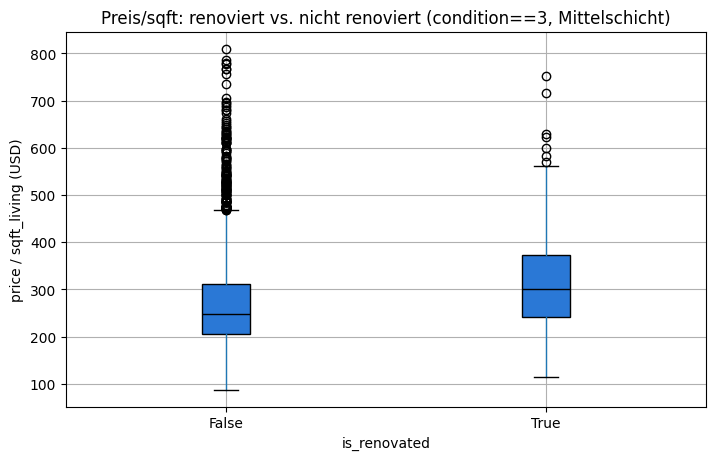

In [20]:
bonnie_cond3 = bonnie[bonnie["condition"] == 3].copy()

print(bonnie_cond3.groupby("is_renovated")[["price", "price_per_sqft"]].agg(["count", "median", "mean"]))

median_price_reno = bonnie_cond3.loc[bonnie_cond3["is_renovated"], "price"].median()
median_price_noreno = bonnie_cond3.loc[~bonnie_cond3["is_renovated"], "price"].median()
price_uplift_pct = (median_price_reno / median_price_noreno - 1) * 100

median_psf_reno = bonnie_cond3.loc[bonnie_cond3["is_renovated"], "price_per_sqft"].median()
median_psf_noreno = bonnie_cond3.loc[~bonnie_cond3["is_renovated"], "price_per_sqft"].median()
psf_uplift_pct = (median_psf_reno / median_psf_noreno - 1) * 100

print(f"\nMedian-Preis renoviert: {median_price_reno:,.0f} $ vs. nicht renoviert: {median_price_noreno:,.0f} $ -> +{price_uplift_pct:.1f} %")
print(f"Median-Preis/sqft renoviert: {median_psf_reno:,.0f} $ vs. nicht renoviert: {median_psf_noreno:,.0f} $ -> +{psf_uplift_pct:.1f} %")
print("Korrelation is_renovated <-> price:", bonnie_cond3["is_renovated"].astype(int).corr(bonnie_cond3["price"]).round(2))

fig, ax = plt.subplots()
bonnie_cond3.boxplot(column="price_per_sqft", by="is_renovated", ax=ax, patch_artist=True,
                     boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
                     medianprops={"color": "black"})
ax.set_title("Preis/sqft: renoviert vs. nicht renoviert (condition==3, Mittelschicht)")
ax.set_xlabel("is_renovated")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Innerhalb von `condition == 3` in Mittelschicht-Nachbarschaften kosten bereits renovierte Häuser (201 von 4.439, ca. 4.5 %) median **635.500 $** vs. **465.000 $** bei nicht renovierten – ein Aufschlag von **+36,7 %** beim absoluten Preis bzw. **+21,7 %** beim Preis pro Quadratfuß (301 $ vs. 247 $). Korrelation `is_renovated` ↔ `price`: **0.14** – etwas stärker als am Gesamtmarkt (0.12).

**Einordnung / ROI-Vorbehalt:** Der Datensatz enthält keine Renovierungskosten, daher lässt sich kein exakter ROI (Gewinn abzüglich Kosten) berechnen – nur die Preisdifferenz. Typische Renovierungskosten für ein Einfamilienhaus dieser Größenordnung (Küche, Bad, kosmetische Auffrischung) liegen laut gängigen Branchenschätzungen grob bei 20.000–80.000 $ – verglichen mit einem Median-Aufschlag von rund **170.500 $** wirkt eine Renovierung finanziell attraktiv. **Aber:** Die renovierte Gruppe ist klein (201 Häuser) und nicht zufällig ausgewählt – Eigentümer, die renovieren, pflegen ihr Haus möglicherweise auch sonst besser (nicht erfasste Faktoren), sodass ein Teil des Aufschlags nicht direkt auf die Renovierung selbst zurückzuführen sein muss. **Für Bonnie heißt das:** Die Daten sprechen tendenziell für eine Renovierung vor dem Verkauf, aber die tatsächliche Kostenseite muss sie selbst kalkulieren – die Preisdifferenz allein ist ein Signal, ersetzt aber keine echte Kostenschätzung.

#### `grade` innerhalb der Mittelschicht-Nachbarschaften (Kontext)

Zur Einordnung: Gilt der starke Zusammenhang zwischen `grade` und Preis (3.1, Korrelation 0.67) auch innerhalb der Mittelschicht-Nachbarschaften, oder war er – wie in der alten, budget-limitierten Analyse – nur ein Artefakt des Budget-Deckels?

       count  median    mean
grade                       
4          9 463.158 392.937
5        104 272.636 322.940
6        631 289.773 311.444
7       3102 263.786 280.844
8       1961 249.714 266.147
9        689 231.502 256.063
10       194 268.254 303.472
11        82 275.172 312.792
12        15 351.931 390.756
13         4 348.671 423.526

Korrelation grade <-> price (Mittelschicht-Segment): 0.65


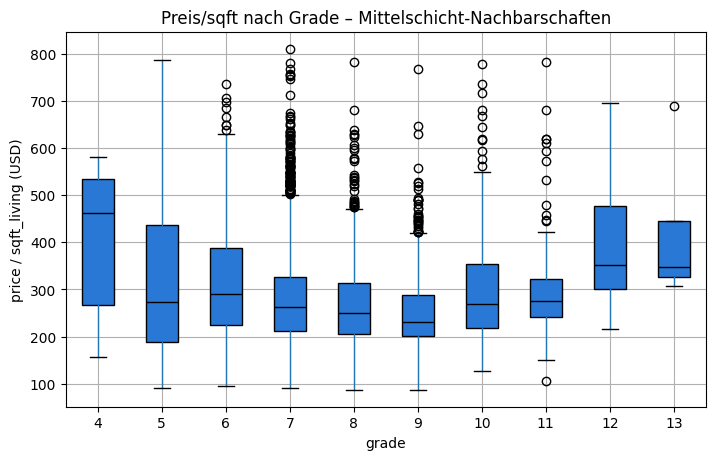

In [21]:
bonnie_grade = bonnie.groupby("grade")["price_per_sqft"].agg(["count", "median", "mean"])
print(bonnie_grade)
print("\nKorrelation grade <-> price (Mittelschicht-Segment):", bonnie["grade"].corr(bonnie["price"]).round(2))

fig, ax = plt.subplots()
bonnie.boxplot(column="price_per_sqft", by="grade", ax=ax, patch_artist=True,
               boxprops={"facecolor": "#2a78d6", "edgecolor": "black"},
               medianprops={"color": "black"})
ax.set_title("Preis/sqft nach Grade – Mittelschicht-Nachbarschaften")
ax.set_xlabel("grade")
ax.set_ylabel("price / sqft_living (USD)")
plt.suptitle("")
plt.show()

**Beobachtung:** Anders als in der alten, budget-limitierten Analyse bricht der Zusammenhang zwischen `grade` und Preis hier **nicht** zusammen – die Korrelation mit dem absoluten Preis bleibt mit **0.65** fast identisch zum Gesamtmarkt (0.67). Der Preis *pro Quadratfuß* verläuft dagegen nicht streng monoton über die Grades (z. B. niedriger bei Grade 8–9 als bei Grade 6–7) – das ist aber ein bekannter, allgemeiner Immobilieneffekt (kleinere Häuser haben tendenziell einen höheren Preis pro Quadratfuß) und kein Bonnie-spezifisches Problem. Für Bonnie ist `grade` als Kontextvariable relevant, aber nicht der Kern ihrer Frage – sie kann ihren eigenen Grade i.d.R. nicht ändern, nur den Zustand (Renovierung).

## Zusammenfassung Hypothese 2 (Renovation ROI)

| Faktor | Gesamtmarkt | Mittelschicht-Nachbarschaften (Bonnies Segment) |
|---|---|---|
| `grade` | Starker Treiber (Korrelation 0.67) | Weiterhin starker Treiber (Korrelation 0.65) – kein Budget-Deckeneffekt mehr |
| `condition` | Schwach (Korrelation 0.04) | `condition == 3`: **10 % Discount** ggü. besseren Zuständen (249 $ vs. 276 $/sqft) |
| Renovierung (condition==3) | Moderat (Korrelation 0.12), +35 % Median-Preis | **+36,7 %** Median-Preis, **+21,7 %** Preis/sqft bei renovierten Häusern (Korrelation 0.14) |

**Fazit für Bonnie Brown (Seller):** Bonnies Haus in `condition == 3` verkauft sich in ihrer Mittelschicht-Nachbarschaft tendenziell zu einem niedrigeren Preis pro Quadratfuß als besser bewertete Häuser. Eine Renovierung vor dem Verkauf zeigt einen deutlichen Preisaufschlag (+36,7 % Median-Preis, +21,7 % pro sqft) – deutlich stärker als in der ursprünglichen (fehlerhaften) Buyer-Analyse (+7 %). **Empfehlung:** Eine Renovierung vor dem Verkauf erscheint auf Basis der Preisdaten lohnenswert, sofern die tatsächlichen Renovierungskosten deutlich unter dem beobachteten Preisaufschlag (Median ca. 170.500 $) liegen – das muss Bonnie mit einer echten Kostenschätzung abgleichen, da der Datensatz keine Renovierungskosten enthält und die renovierte Stichprobe klein ist (201 Häuser).

**Nächste Schritte:** Hypothese 1 (Location Value) und Hypothese 3 (Timing) stehen noch aus und müssen ebenfalls an Bonnies Rolle als Verkäuferin angepasst werden – vermutlich durch Hashim und Evelyn.

## Summary: Hypothesis 2 – Renovation ROI (English)

| Factor | Overall market | Middle-class neighborhoods (Bonnie's segment) |
|---|---|---|
| `grade` | Strong driver (correlation 0.67) | Still a strong driver (correlation 0.65) — no budget-ceiling artifact here |
| `condition` | Weak (correlation 0.04) | `condition == 3`: **10% discount** vs. better-rated homes ($249 vs. $276/sqft) |
| Renovation (condition==3) | Moderate (correlation 0.12), +35% median price | **+36.7%** median price, **+21.7%** price/sqft for renovated homes (correlation 0.14) |

**Conclusion for Bonnie Brown (Seller):** Bonnie's home in `condition == 3` tends to sell for a lower price per square foot than better-rated homes in her middle-class neighborhood. Renovating before selling shows a clear price premium (+36.7% median price, +21.7% per sqft) — notably larger than the original (flawed) buyer-framed analysis found (+7%). **Recommendation:** based on the price data alone, renovating before selling looks worthwhile, provided actual renovation costs stay well below the observed premium (median ~$170,500) — Bonnie needs to check this against a real cost estimate, since the dataset contains no renovation-cost data and the renovated sample is small (201 homes).

**Next steps:** Hypothesis 1 (location value) and Hypothesis 3 (timing) are still open and also need to be reframed around Bonnie's role as a seller — likely by Hashim and Evelyn.